<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/A_Comparative_Machine_Learning_Framework_for_Short_Term_Electricity_Demand_Forecasting_Using_Engineered_Temporal_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install xgboost tensorflow statsmodels


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import lightgbm as lgb
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/PGCB_date_power_demand.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

In [13]:
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

df['renewables'] = df[['hydro','solar','wind']].fillna(0).sum(axis=1)

df['import_total'] = df[['india_bheramara_hvdc',
                         'india_tripura',
                         'india_adani',
                         'nepal']].fillna(0).sum(axis=1)

# LAG FEATURES
for lag in [1,2,3,6,12,24]:
    df[f'lag_{lag}'] = df['demand_mw'].shift(lag)

# ROLLING (NO LEAKAGE)
for w in [6,12,24]:
    df[f'roll_{w}'] = df['demand_mw'].shift(1).rolling(w).mean()

df['is_evening_peak'] = df['remarks'].fillna('').str.contains('Evening_Peak').astype(int)
df['is_day_peak'] = df['remarks'].fillna('').str.contains('Day_Peak').astype(int)

df = df.dropna().reset_index(drop=True)

In [14]:
features = [
    'hour','dayofweek','month','is_weekend',
    'is_evening_peak','is_day_peak',
    'renewables','import_total'
] + [f'lag_{i}' for i in [1,2,3,6,12,24]] \
  + [f'roll_{i}' for i in [6,12,24]]

X = df[features]
y = df['demand_mw']

In [15]:
split = int(len(df)*0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42
    ),

    "KNN": KNeighborsRegressor(n_neighbors=7),

    "SVR": SVR(C=10, kernel='rbf'),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=64
    ),

    "XGBoost": XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

In [18]:
results = {}

for name, model in models.items():

    if name in ["SVR", "KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / (y_test + 1e-6))) * 100

    results[name] = [mae, rmse, mape]

    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}")

Linear Regression: MAE=275.93, RMSE=352.31, MAPE=2.10
Random Forest: MAE=265.69, RMSE=356.30, MAPE=2.00
KNN: MAE=513.45, RMSE=632.06, MAPE=3.84
SVR: MAE=2354.60, RMSE=2667.33, MAPE=16.32
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1227
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 17
[LightGBM] [Info] Start training from score 11522.517964
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

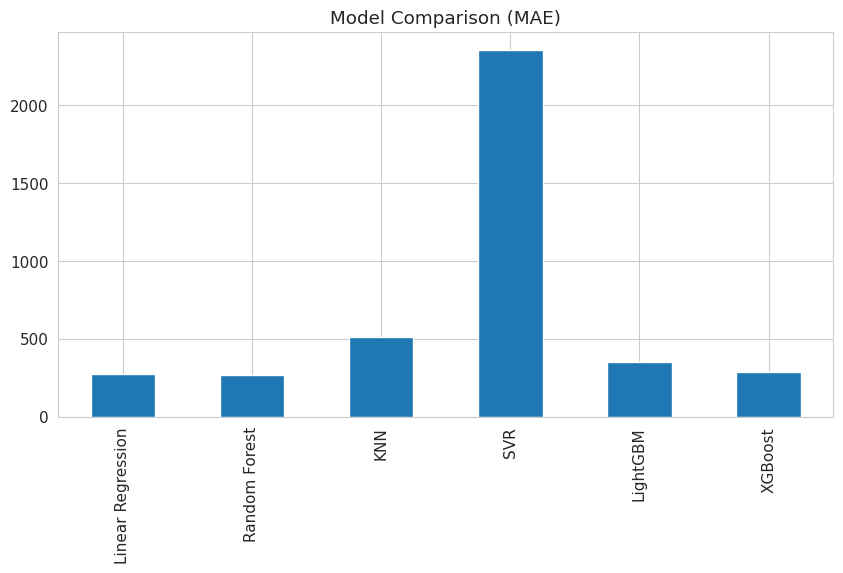

In [19]:
results_df = pd.DataFrame(results, index=["MAE","RMSE","MAPE"]).T

plt.figure(figsize=(10,5))
results_df['MAE'].plot(kind='bar')
plt.title("Model Comparison (MAE)")
plt.show()

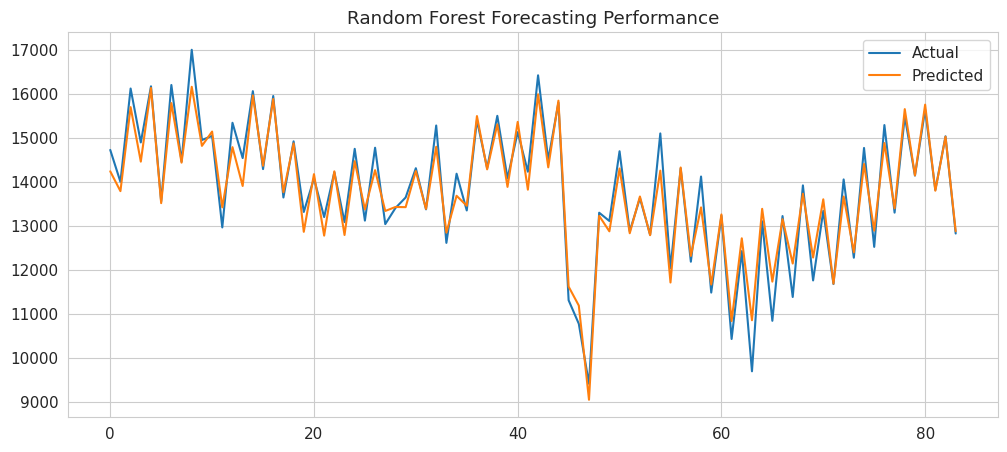

In [22]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ---------------- FIXED MODEL ----------------
best_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

# ---------------- TRAIN ----------------
best_model.fit(X_train, y_train)

# ---------------- PREDICT ----------------
pred = best_model.predict(X_test)

# ---------------- PLOT ----------------
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred[:300], label="Predicted")
plt.legend()
plt.title("Random Forest Forecasting Performance")
plt.show()

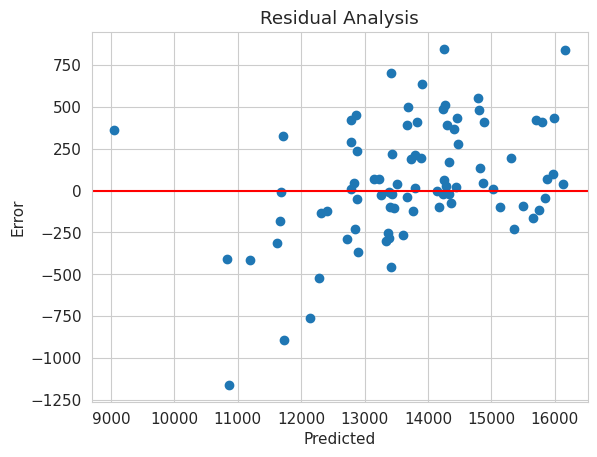

In [23]:
residuals = y_test - pred

plt.figure()
plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.title("Residual Analysis")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

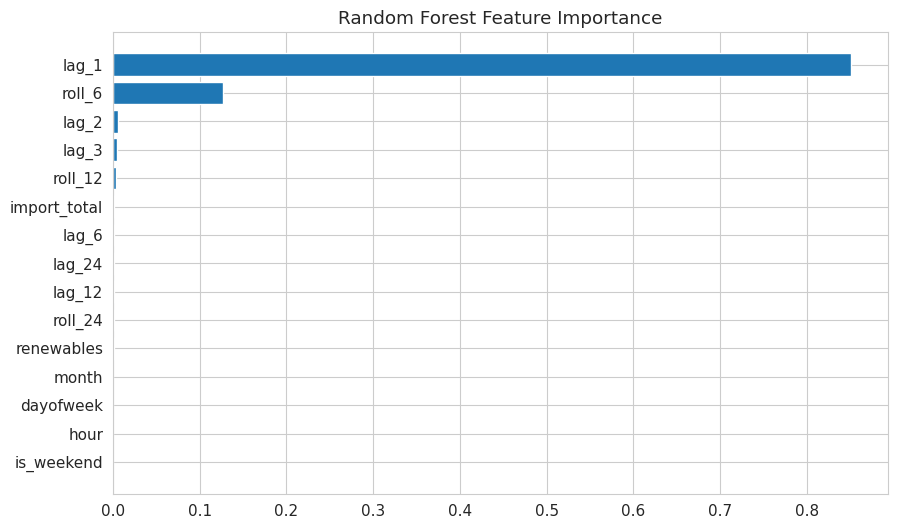

In [24]:
plt.figure(figsize=(10,6))

importances = best_model.feature_importances_
indices = importances.argsort()[-15:]

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.title("Random Forest Feature Importance")
plt.show()

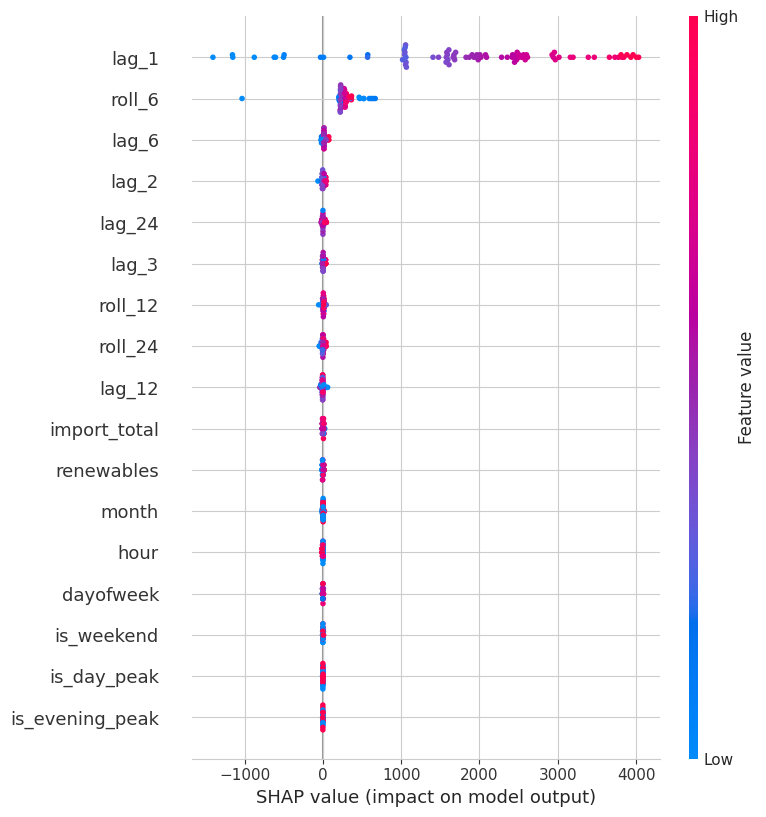

In [28]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 1. Summary plot (global importance)
shap.summary_plot(shap_values, X_test)

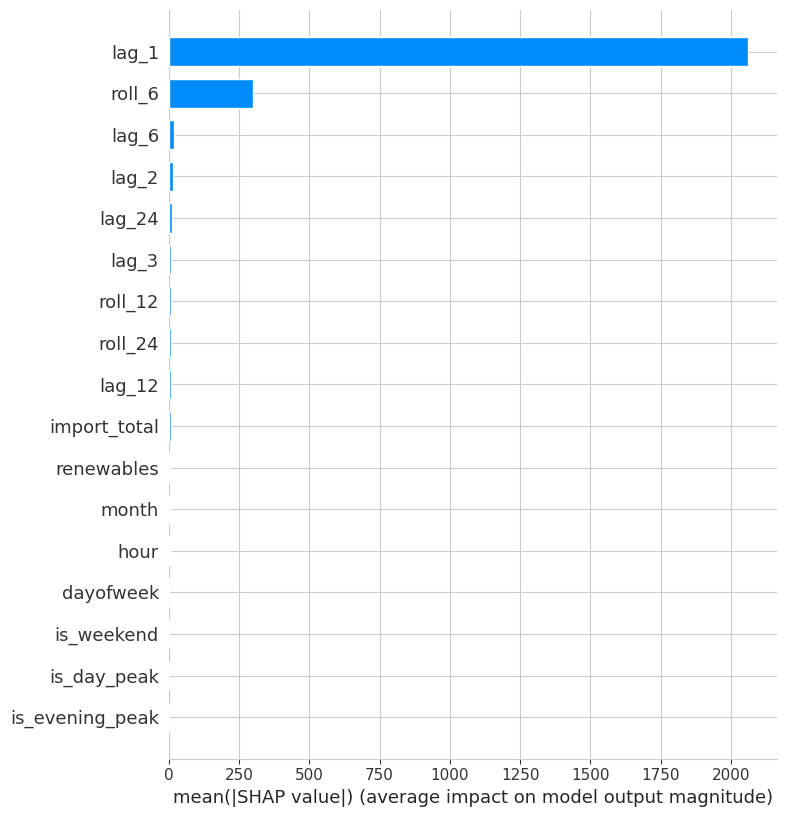

In [29]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [33]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import shap

In [34]:
results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test, scaled=False):

    start = time.time()

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    end = time.time()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    runtime = end - start

    results[name] = [mae, rmse, r2, runtime]

    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}, Time={runtime:.2f}s")

    return model, pred

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import lightgbm as lgb

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=64
)

lr_model = LinearRegression()

knn_model = KNeighborsRegressor(n_neighbors=7)

svr_model = SVR(C=10, kernel='rbf')

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
rf_model, rf_pred = evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)

xgb_model, xgb_pred = evaluate_model("XGBoost", xgb_model, X_train, X_test, y_train, y_test)

lgb_model, lgb_pred = evaluate_model("LightGBM", lgb_model, X_train, X_test, y_train, y_test)

lr_model, lr_pred = evaluate_model("Linear Regression", lr_model, X_train, X_test, y_train, y_test)

knn_model, knn_pred = evaluate_model("KNN", knn_model, X_train_scaled, X_test_scaled, y_train, y_test)

svr_model, svr_pred = evaluate_model("SVR", svr_model, X_train_scaled, X_test_scaled, y_train, y_test)

Random Forest: MAE=265.69, RMSE=356.30, R2=0.9459, Time=2.18s
XGBoost: MAE=288.29, RMSE=367.25, R2=0.9426, Time=1.81s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1227
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 17
[LightGBM] [Info] Start training from score 11522.517964
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

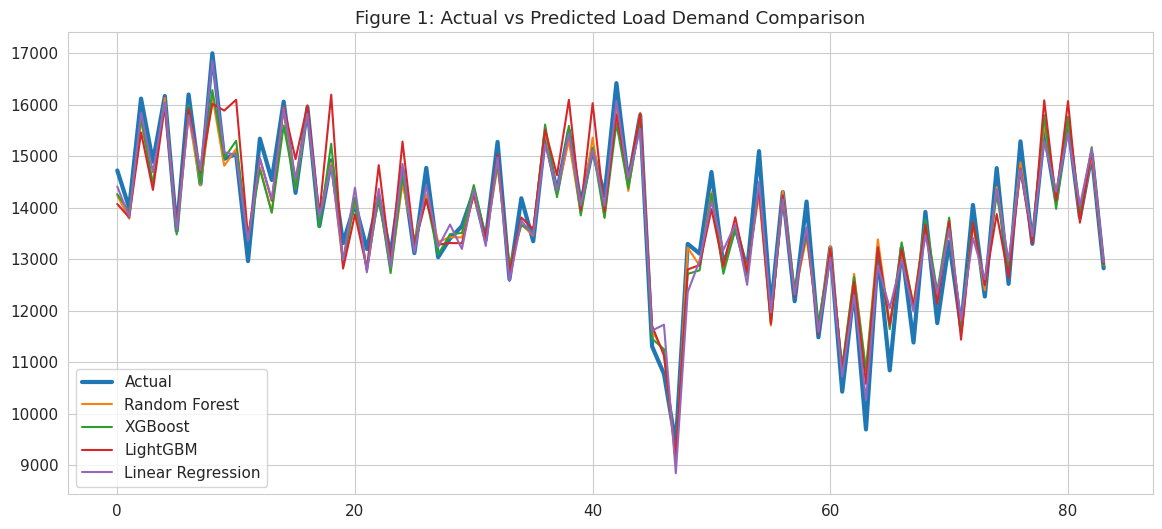

In [42]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:300], label="Actual", linewidth=3)
plt.plot(rf_pred[:300], label="Random Forest")
plt.plot(xgb_pred[:300], label="XGBoost")
plt.plot(lgb_pred[:300], label="LightGBM")
plt.plot(lr_pred[:300], label="Linear Regression")

plt.title("Figure 1: Actual vs Predicted Load Demand Comparison")
plt.legend()
plt.show()